In [ ]:
pip install numpy nibabel scikit-learn tensorflow matplotlib seaborn reportlab pillow wandb

In [111]:
import os

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import nibabel as nib
 
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, GroupNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model


import matplotlib.pyplot as plt
import gc
import seaborn as sns
import random
from scipy.ndimage import zoom
from skimage.transform import resize

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
from tensorflow.keras import backend as K

#import wandb

In [2]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
            print("Memory Growth habilitado para a GPU")
        print("GPU habilitada com sucesso!")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

tf.get_logger().setLevel('ERROR')

Memory Growth habilitado para a GPU
GPU habilitada com sucesso!


I0000 00:00:1788444069.694247  679767 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788444069.708989  679767 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788444069.709053  679767 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [133]:
# FUNÇÕES

# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def load_nifti_paths(base_dir, class_names):
    image_paths = []
    labels = []
    
    # Caminhos das subpastas
    for label in class_names:
        label_dir = os.path.join(base_dir, label)
        for fname in os.listdir(label_dir):
            img_path = os.path.join(label_dir, fname)
            image_paths.append(img_path)
            labels.append(label)

    # Codificando os rótulos
    label_encoder = LabelEncoder()

    # Inverter a ordem das classes explicitamente
    label_encoder.classes_ = np.array(class_names)

    # Convertendo a lista de rótulos para um array NumPy
    labels_array = np.array(labels)

    # Codificando os rótulos (agora 'cn' será 0 e 'ad' será 1)
    labels_encoded = label_encoder.transform(labels_array)

    # Transformando os rótulos para one-hot encoding
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Embaralhar os dados
    image_paths, labels_one_hot = shuffle(image_paths, labels_one_hot, random_state=42)

    return image_paths, labels_one_hot, label_encoder.classes_

def load_nifti_data_balanced(base_dir, class_names, target=1000):
    images = []
    labels = []
    paths = []
    
    # Caminhos das subpastas
    for label in class_names:
        print(f"carregando diretório {label}")
        label_dir = os.path.join(base_dir, label)
        count = 0

        names = os.listdir(label_dir)
        #np.random.shuffle(names)
        for fname in names:
            #if count < target:
            img_path = os.path.join(label_dir, fname)
            img = nib.load(img_path).get_fdata(dtype=np.float16)
            paths.append(img_path)
            images.append(img)
            labels.append(label)
            count += 1

        print(f"diretório carregado {count}")

    # Codificando os rótulos
    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Convertendo para arrays NumPy
    images = np.array(images).reshape((-1, *images[0].shape, 1))
    labels_one_hot = np.array(labels_one_hot)
    
    # Embaralhar os dados
    images, labels_one_hot, paths = shuffle(images, labels_one_hot, paths, random_state=42)
    
    return images, labels_one_hot, paths, label_encoder.classes_

def nifti_data_generator_3d(images_array, labels, batch_size, gc_every=20):
    total_n = len(images_array)
    batch_count = 0

    while True:
        for i in range(0, total_n, batch_size):
            final = min(i + batch_size, total_n)
            batch_images = np.array(images_array[i: final])
            batch_labels = np.array(labels[i:final])

            # gc.collect() a cada lote deixa o treino bem mais lento sem ganho real
            # de RAM -- roda so de vez em quando pra limpar os lotes ja descartados
            batch_count += 1
            if batch_count % gc_every == 0:
                gc.collect()

            yield batch_images, batch_labels


# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def nifti_data_generator_3d_path(image_paths, labels, batch_size, size):
    cache_size = batch_size*size
    while True:
        for i in range(0, len(image_paths), cache_size):
            final = min(i + cache_size, len(image_paths))
            batch_paths = image_paths[i:final]
            batch_labels = labels[i:final]
            images = []

            for path in batch_paths:
                # Carregar a imagem NIfTI e garantir o formato correto
                img = nib.load(path).get_fdata(dtype=np.float16)  # Shape original: 
                img = img[..., np.newaxis]       # Adicionar a dimensão do canal: 
                images.append(img)
            
            # Converter lista para array NumPy e garantir o shape correto
            images = np.array(images) 
            batch_labels = np.array(batch_labels)

            # Liberar memória
            gc.collect()
            
            yield images, batch_labels

            import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_probs, output_dir, mode, title):
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:
        y_true = np.argmax(y_true, axis=1)

    if len(y_probs.shape) > 1 and y_probs.shape[1] > 1:
        y_probs = y_probs[:, 1]

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel('False Positive Rate', fontsize=18)
    plt.ylabel('True Positive Rate', fontsize=18)
    plt.title(f'Receiver Operating Characteristic ({title})', fontsize=24)
    plt.legend(loc="lower right", fontsize=15)
    
    plt.savefig(os.path.join(output_dir, f'roc_curve_{mode}.png'))
    plt.show()
    plt.close()
    
    print(f"AUC ({mode}): {roc_auc:.4f}")

# realizar predições e armazenar em um vetor
def get_predictions(images, labels, batch_size, best_model, dir, subset, title):
    pred = []

    for i in range(0, len(images), batch_size):
        final = min(i + batch_size, len(images))
        
        # Fazendo predição para o lote atual
        batch_pred = best_model.predict(images[i:final])
        pred.append(batch_pred)

    # Concatenando as predições e os rótulos verdadeiros
    pred = np.concatenate(pred)

    # Chamar a função
    plot_roc_curve(labels, pred, dir, subset, title)

    # Convertendo as predições para rótulos (a classe com maior probabilidade)
    true_labels = np.argmax(labels, axis=1)
    pred_labels = np.argmax(pred, axis=1)
    return pred_labels, true_labels, pred

# gerar curva AUC
def save_auc(test_pred, test_true_labels, results_dir, subset):
    if len(test_pred.shape) > 1 and test_pred.shape[1] > 1:
        y_probs = test_pred[:, 1]
    else:
        y_probs = test_pred

    auc_value = roc_auc_score(test_true_labels, y_probs)

    # Salvar o valor em um arquivo de texto
    with open(os.path.join(results_dir, f"{subset}_auc.txt"), "w") as f:
        f.write(f"AUC Score: {auc_value:.4f}")

    print(f"AUC da Validação: {auc_value:.4f}")

def plot_training_history(history, dir):
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['categorical_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.savefig(os.path.join(dir, 'training_history.png'))

    plt.show()

def plot_confusion_matrix(y_true, y_pred, dir, subset, class_names, title):
    # Calcular a matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # Plotando a matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,  annot_kws={"size": 20})
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.xlabel('Predictions', fontsize=24)
    plt.ylabel('Ground Truth', fontsize=24)
    plt.title(f'Confusion Matrix ({title})', fontsize=28)
    plt.savefig(f'{dir}/{subset}_confusion_matrix.png')
    plt.show()

def get_classification_report(y_true, y_pred, dir, subset):
    # Gerar relatório
    report = classification_report(y_true, y_pred)
    print(report)

    # Escrevendo o relatório em um arquivo .txt
    with open(os.path.join(dir, f"{subset}_classification_report.txt"), "w") as file:
        file.write(report)

    # Função para carregar uma imagem NIfTI e extrair uma fatia específica do eixo Z
def load_nifti_image_pdf(file_path):
    img = nib.load(file_path) 
    data = img.get_fdata(dtype=np.float16)  
    slice_2d = data[2, :, :]

    # implementar lógica de retornar vetor com cada fatia como imagem única

    return slice_2d

# Função para criar o PDF
def create_pdf(y_paths, y_images, y_true_labels, y_pred_labels, y_pred, output_pdf_path, class_names):
    c = canvas.Canvas(output_pdf_path, pagesize=letter)
    width, height = letter  # Dimensões da página no PDF

    #for image, name in zip(y_images, y_paths):
    for i in range(0, len(y_images)):
        true = ''
        pred = ''
        # Carregar a imagem NIfTI e obter a fatia 2D no eixo Z
        # nifti_image = load_nifti_image_pdf(item)
        nifti_image = y_images[i][:, :, 88, 0]

        # Converter a fatia 2D para uma imagem 8-bit (grayscale) para visualização
        img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
        img = img.convert("RGB")  # Garantir que a imagem tenha 3 canais (RGB)

        # Redimensionar a imagem para se ajustar ao tamanho da página
        img_width, img_height = img.size
        aspect_ratio = img_height / float(img_width)
        new_width = width * 0.2  # Definir largura como 80% da largura da página
        new_height = new_width * aspect_ratio
        img = img.resize((int(new_width), int(new_height)))

        # Criar um arquivo temporário para salvar a imagem
        with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as temp_file:
            temp_file_path = temp_file.name
            img.save(temp_file_path)

        # configurar para printar as 7 fatias em uma página inteira, com as informações de label predito e esperado

        # Colocar a imagem no PDF usando o caminho temporário
        if i % 12 < 4:
            x = 80
        elif i % 12 < 8:
            x = width - 2.35*new_width - 80
        else:
            x = width - new_width - 80

        y = height - (new_height + 80)*((i%4)+1)

        c.drawImage(temp_file_path, x, y, width=new_width, height=new_height)

        # Escrever os rótulos
        true_label = y_true_labels[i]
        pred_label = y_pred_labels[i]

        #ver como transformar os labels de maneira inteligente
        true = class_names[true_label]
        pred = class_names[pred_label]

        # Definir a cor para os rótulos
        if true_label == pred_label:
            pred_color = (0, 1, 0)  # Verde
        else:
            pred_color = (1, 0, 0)  # Vermelho
        
        #Nome paciente (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+24, y+new_height+50, f"{os.path.basename(y_paths[i])}")

        # Rótulo esperado (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+26, y+new_height+35, f"Expected: {true}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+20, f"Predicted: {pred}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+5, f"Prob: {max(y_pred[i])*100:.2f}%")

        # Avançar para a próxima imagem
        i += 1
        
        # Adicionar uma nova página no PDF a cada 2 imagens (se necessário)
        if i % 12 == 0:  # Por exemplo, a cada 2 imagens, adicionamos uma nova página
            c.showPage()

    # Salvar o PDF
    c.save()

def create_model_3d_best(input_shape, n_classes):
    model = Sequential([        
        Input(shape=input_shape),  # Formato de entrada: (1, 145, 182, 155)

        # Camada 1 - Filtro 3x3
        Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        LeakyReLU(negative_slope=0.3),  
        MaxPooling3D(pool_size=(2, 2, 2), padding='same'),
        Dropout(0.4),

        # Camada 2 - Filtro 5x5
        Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        LeakyReLU(negative_slope=0.3),  
        MaxPooling3D(pool_size=(2, 2, 2), padding='same'),
        Dropout(0.4),

        # Camada 3 - Filtro 5x5
        Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        LeakyReLU(negative_slope=0.3),  
        MaxPooling3D(pool_size=(2, 2, 2), padding='same'),
        Dropout(0.4),

        # Camada de saída convolucional
        Flatten(),

        # Camadas densas
        Dense(16, kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        Dropout(0.4),
        LeakyReLU(negative_slope=0.3),  

        # Camadas densas
        Dense(8, kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        Dropout(0.4),
        LeakyReLU(negative_slope=0.3),  

        # Camada de saída
        Dense(n_classes, activation='softmax')
    ])
    
    return model

def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(32, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)
    
    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(32, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

def plot_training_history_gradcam(history, dir):
    # Criamos 3 subplots agora
    plt.figure(figsize=(18, 5))

    # 1. Plot Loss Total e de Classificação
    plt.subplot(1, 3, 1)
    plt.plot(history.history['total_loss'], label='Total Loss (BCE + SFR)')
    if 'classification_loss' in history.history:
        plt.plot(history.history['classification_loss'], label='Classification Loss (BCE)')
    plt.title('Loss Analysis')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # 2. Plot Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(history.history['categorical_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # 3. Plot Saliency Loss (A "punição" do Grad-CAM)
    plt.subplot(1, 3, 3)
    if 'saliency_loss' in history.history:
        plt.plot(history.history['saliency_loss'], label='Saliency Loss (SFR)', color='red')
        plt.title('Saliency Regularization Term')
        plt.xlabel('Epochs')
        plt.ylabel('Penalty Intensity')
        plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(dir, 'training_history_gradcam.png'))
    plt.show()

In [4]:
# Definindo caminhos
# dir_base_syn = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/3D_BRAIN_NORM"
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED"
#dir_base = "/mnt/c/Users/Team Taiane/Desktop/ADNI/FULL_ADNI/3D_REDUCED"

train_dir = f'{dir_base}/train'
val_dir = f'{dir_base}/validation'
test_dir = f'{dir_base}/test'
results_dir = f'{dir_base}/results/neurips_results/grad_loss_mask_pre'
os.makedirs(results_dir, exist_ok=True)

# class_names = ['cn', 'emci', 'mci', 'lmci', 'ad']
class_names = ['cn', 'ad']

n_classes = len(class_names)

In [5]:
n = len(os.listdir(results_dir))

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir, f'test_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir, f"test_{n}")):
            os.remove(os.path.join(results_dir,  f"test_{n}", item))
        os.removedirs(os.path.join(results_dir, f'test_{n}'))
        n -= 1

folder_name = f"test_{str(n+1)}"
results_dir = os.path.join(results_dir, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_7 criada


**[OBSOLETO — substituido pelo cache memmap na celula de k-fold]**

`load_nifti_data_balanced` montava uma lista com todos os volumes, copiava tudo num
`np.array` e copiava de novo no `shuffle` (fancy indexing) — picos de ~2x o dataset
**antes de qualquer fold comecar**, que era o que derrubava o kernel. O pool de treino
agora e escrito uma vez num `.npy` pre-alocado e lido por lote direto do disco.


**[OBSOLETO — validation entrou no pool do k-fold, carregado via cache memmap]**


## Treino com Grad-CAM

In [8]:
print(os.listdir('../pre_processing/mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/'))

# Carregar máscara
mask = nib.load('../pre_processing/mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/mni_icbm152_t1_tal_nlin_asym_09c_mask.nii').get_fdata()
mask_crop = mask[18:174, 17:212, 15:175]

mask_crop = resize(mask_crop, (18, 22, 18), order=0, preserve_range=True, anti_aliasing=False)
mask_crop = (mask_crop > 0.5).astype(float)
mask_crop = 1.0 - mask_crop
mask_crop = tf.cast(mask_crop, tf.float16)

['mni_icbm152_csf_tal_nlin_asym_09c.nii', 'mni_icbm152_gm_tal_nlin_asym_09c.nii', 'mni_icbm152_pd_tal_nlin_asym_09c.nii', 'mni_icbm152_t1_tal_nlin_asym_09c.nii', 'mni_icbm152_t1_tal_nlin_asym_09c_eye_mask.nii', 'mni_icbm152_t1_tal_nlin_asym_09c_face_mask.nii', 'mni_icbm152_t1_tal_nlin_asym_09c_mask.nii', 'mni_icbm152_t2_tal_nlin_asym_09c.nii', 'mni_icbm152_wm_tal_nlin_asym_09c.nii']


I0000 00:00:1788444259.746988  679767 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788444259.747077  679767 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788444259.747113  679767 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788444259.889451  679767 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788444259.889519  679767 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-03

(18, 22, 18)


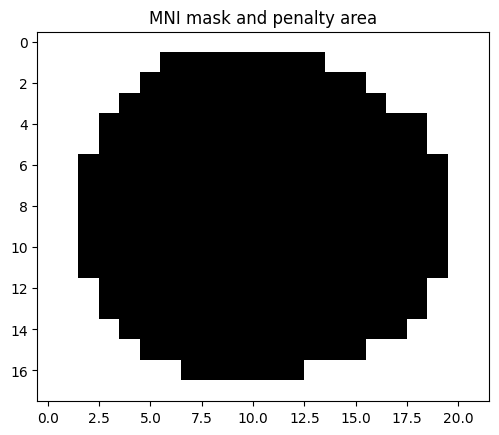

In [9]:
# print(train_images[0].shape)
print(mask_crop.shape)
plt.imshow(mask_crop[:, :, 10], cmap='grey', alpha=1)
# plt.imshow(train_images[0][:, :, 90], cmap='grey', alpha=1)
plt.title("MNI mask and penalty area")
plt.show()

In [10]:
def custom_binary_crossentropy(y_true, y_pred, alpha, mean_grad):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

    term1 = y_true * tf.math.log(y_pred)
    term2 = (1.0 - y_true) * tf.math.log(1.0 - y_pred)
    term3 = alpha * tf.sum(tf.multiply(mask_crop, mean_grad))

    loss_individual = -(term1 + term2 + term3)

    return tf.reduce_mean(loss_individual, axis=-1) # Retorna a média da perda para o batch inteiro (se quiser mudar, fica a seu critério)

In [ ]:
import tensorflow as tf

class SFRModel(tf.keras.Model):
    def __init__(self, model, alpha, mask_crop, last_conv_layer_name, **kwargs):
        super(SFRModel, self).__init__(**kwargs)
        
        self.model = model
        self.alpha = alpha
        self.mask_crop = tf.cast(mask_crop, tf.float32)
        self.last_conv_layer_name = last_conv_layer_name
        
        # O Keras rastreia esses atributos automaticamente!
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.saliency_tracker = tf.keras.metrics.Mean(name="saliency_loss")
        self.classification_tracker = tf.keras.metrics.Mean(name="classification_loss")
        
        # Inicialização do modelo de gradiente
        # Com alpha=0 o Grad-CAM nunca e usado (train_step/test_step desviam antes),
        # entao nem monta o grad_model -- e um Model extra construido por fold a toa
        self.grad_model = None
        try:
            if alpha != 0:
                conv_layer = self.model.get_layer(self.last_conv_layer_name)
                self.grad_model = tf.keras.models.Model(
                    [self.model.inputs], [conv_layer.output, self.model.output]
                )
        except Exception as e:
            print(f"Aviso: Não foi possível criar o grad_model na inicialização: {e}")

    def get_config(self):
        base_config = super(SFRModel, self).get_config()
        config = {
            "model": self.model, 
            "alpha": self.alpha,
            "mask_crop": self.mask_crop.numpy() if hasattr(self.mask_crop, "numpy") else self.mask_crop,
            "last_conv_layer_name": self.last_conv_layer_name,
        }
        return {**base_config, **config}

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    def train_step(self, data):
        x, y = data
        x = tf.cast(x, tf.float32)
        y = tf.cast(y, tf.float32)

        with tf.GradientTape() as total_tape:
            if self.alpha == 0:
                # alpha=0 zera a penalidade de saliencia de qualquer forma -- pula o
                # Grad-CAM (que exige um GradientTape aninhado, ou seja, diferenciacao
                # de segunda ordem) inteiro em vez de computa-lo so pra multiplicar por 0
                predictions = self.model(x, training=True)
                main_loss = self.compute_loss(x=x, y=y, y_pred=predictions)
                total_loss = main_loss
                mean_saliency_penalty = tf.constant(0.0, dtype=tf.float32)
            else:
                with tf.GradientTape() as gradcam_tape:
                    conv_outputs, predictions = self.grad_model(x, training=True)
                    class_loss = predictions[:, 1]

                grads = gradcam_tape.gradient(class_loss, conv_outputs)
                pooled_grads = tf.reduce_mean(grads, axis=(1, 2, 3))
                heatmap = tf.reduce_sum(tf.multiply(pooled_grads[:, tf.newaxis, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
                heatmap = tf.nn.relu(heatmap)

                heatmap_norm = heatmap / (tf.reduce_sum(heatmap, axis=(1, 2, 3), keepdims=True) + 1e-6)
                saliency_penalty_batch = tf.reduce_sum(heatmap_norm * self.mask_crop, axis=(1, 2, 3))
                mean_saliency_penalty = tf.reduce_mean(saliency_penalty_batch)

                # compute_loss atualiza o tracker interno "loss" automaticamente (com o main_loss)
                main_loss = self.compute_loss(x=x, y=y, y_pred=predictions)
                total_loss = main_loss + (self.alpha * mean_saliency_penalty)

        gradients = total_tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.saliency_tracker.update_state(mean_saliency_penalty)
        self.classification_tracker.update_state(main_loss)

        logs = {
            "total_loss": self.total_loss_tracker.result(),
            "saliency_loss": self.saliency_tracker.result(),
            "classification_loss": self.classification_tracker.result(),
        }
        for metric in self.metrics:
            if metric.name in ("total_loss", "saliency_loss", "classification_loss", "loss"):
                continue
            metric.update_state(y, predictions)
            result = metric.result()
            if isinstance(result, dict):
                logs.update(result)
            else:
                logs[metric.name] = result

        return logs
    
    def test_step(self, data):
        x, y = data
        x = tf.cast(x, tf.float32)
        y = tf.cast(y, tf.float32)

        if self.alpha == 0:
            # mesmo raciocinio do train_step: com alpha=0 a penalidade de saliencia
            # nunca entra no total_loss, entao nem vale computar o Grad-CAM aqui
            predictions = self.model(x, training=False)
            main_loss = self.compute_loss(x=x, y=y, y_pred=predictions)
            total_loss = main_loss
            mean_saliency_penalty = tf.constant(0.0, dtype=tf.float32)
        else:
            with tf.GradientTape() as gradcam_tape:
                conv_outputs, predictions = self.grad_model(x, training=False)
                class_loss = predictions[:, 1]

            grads = gradcam_tape.gradient(class_loss, conv_outputs)
            pooled_grads = tf.reduce_mean(grads, axis=(1, 2, 3))
            heatmap = tf.reduce_sum(
                tf.multiply(pooled_grads[:, tf.newaxis, tf.newaxis, tf.newaxis, :], conv_outputs),
                axis=-1
            )
            heatmap = tf.nn.relu(heatmap)

            heatmap_norm = heatmap / (tf.reduce_sum(heatmap, axis=(1, 2, 3), keepdims=True) + 1e-6)
            saliency_penalty_batch = tf.reduce_sum(heatmap_norm * self.mask_crop, axis=(1, 2, 3))
            mean_saliency_penalty = tf.reduce_mean(saliency_penalty_batch)

            main_loss = self.compute_loss(x=x, y=y, y_pred=predictions)
            total_loss = main_loss + (self.alpha * mean_saliency_penalty)

        self.total_loss_tracker.update_state(total_loss)
        self.saliency_tracker.update_state(mean_saliency_penalty)
        self.classification_tracker.update_state(main_loss)

        logs = {
            "total_loss": self.total_loss_tracker.result(),
            "saliency_loss": self.saliency_tracker.result(),
            "classification_loss": self.classification_tracker.result(),
        }
        for metric in self.metrics:
            if metric.name in ("total_loss", "saliency_loss", "classification_loss", "loss"):
                continue
            metric.update_state(y, predictions)
            result = metric.result()
            if isinstance(result, dict):
                logs.update(result)
            else:
                logs[metric.name] = result

        return logs
    
    @property
    def metrics(self):
        return super().metrics

    def call(self, x):
        return self.model(x)

## K-Fold Cross-Validation (SFR) + treino final em train+val completo

In [ ]:
from sklearn.model_selection import StratifiedKFold
import json

# ===== Pool do k-fold: train + val num cache memmap em disco (test_dir fica de fora) =====
# O pool NUNCA fica inteiro na RAM do kernel: o cache e escrito uma vez, um volume por
# vez, direto num .npy pre-alocado; depois cada lote e lido do arquivo mapeado sob
# demanda. Substitui as celulas 6/7, cujos picos de ~2x o dataset matavam o kernel
# antes mesmo do primeiro fold comecar.

# Para RETOMAR uma execucao interrompida: aponte para a pasta test_N anterior e NAO
# rode de novo a celula que cria test_N+1. None = usa a results_dir atual.
RESUME_FROM = None
if RESUME_FROM:
    results_dir = RESUME_FROM
    print(f"Retomando execucao em {results_dir}")

SHUFFLE_SEED = 42

# o cache e compartilhado entre execucoes -- construido uma unica vez
kfold_cache_dir = os.path.join(dir_base, "kfold_cache")
os.makedirs(kfold_cache_dir, exist_ok=True)
kfold_images_path = os.path.join(kfold_cache_dir, "kfold_images.npy")
kfold_labels_path = os.path.join(kfold_cache_dir, "kfold_labels.npy")
kfold_paths_path = os.path.join(kfold_cache_dir, "kfold_paths.json")


def build_kfold_cache(base_dirs, images_path, labels_path, paths_path, seed=SHUFFLE_SEED):
    # Escreve o pool train+val num .npy pre-alocado, um volume por vez: o pico de RAM
    # e o de UM volume. O embaralhamento e feito na LISTA de arquivos, antes de
    # carregar, entao nunca existe uma copia embaralhada do array inteiro.
    entries = []
    for base_dir in base_dirs:
        for class_idx, label in enumerate(class_names):
            label_dir = os.path.join(base_dir, label)
            for fname in sorted(os.listdir(label_dir)):
                entries.append((os.path.join(label_dir, fname), class_idx))

    random.Random(seed).shuffle(entries)

    total = len(entries)
    if total == 0:
        raise ValueError(f"Nenhum volume encontrado em {base_dirs}")

    shape = nib.load(entries[0][0]).header.get_data_shape()
    print(f"Pool k-fold: {total} volumes, shape {shape}")

    images = np.lib.format.open_memmap(
        images_path, mode='w+', dtype=np.float16, shape=(total, *shape, 1)
    )
    labels = np.zeros((total, n_classes), dtype=np.float16)

    for i, (path, class_idx) in enumerate(entries):
        images[i, ..., 0] = nib.load(path).get_fdata(dtype=np.float32).astype(np.float16)
        labels[i, class_idx] = 1.0
        if (i + 1) % 50 == 0 or (i + 1) == total:
            print(f"  {i + 1}/{total} volumes escritos")

    images.flush()
    del images
    gc.collect()
    np.save(labels_path, labels)
    with open(paths_path, "w") as f:
        json.dump([p for p, _ in entries], f)


if os.path.exists(kfold_images_path) and os.path.exists(kfold_labels_path):
    print(f"Cache do pool ja existe em {kfold_cache_dir} -- reaproveitando.")
else:
    print("Gerando cache do pool k-fold (train + validation)...")
    build_kfold_cache([train_dir, val_dir], kfold_images_path, kfold_labels_path, kfold_paths_path)

kfold_images = np.load(kfold_images_path, mmap_mode='r')   # fica no disco
kfold_labels = np.load(kfold_labels_path)                  # (N, n_classes), cabe na RAM
with open(kfold_paths_path) as f:
    kfold_paths = json.load(f)
kfold_y = np.argmax(kfold_labels, axis=1)
sample_shape = kfold_images.shape[1:]
print(f"Pool: {len(kfold_images)} volumes | sample_shape {sample_shape}")

N_FOLDS = 5
FOLD_ALPHA = 0.00  # mesmo alpha do treino original
FOLD_EPOCHS = 200
FOLD_PATIENCE = 30
batch_size = 16

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_metrics = []  # cada item: {"fold", "val_accuracy", "val_auc"}


def memmap_batch_generator(images, labels, indices, batch_size):
    # Le cada lote direto do .npy mapeado -- o pool fica no disco, nao na RAM.
    # Os indices ficam em ordem crescente de proposito: leitura sequencial no arquivo
    # mapeado e bem mais rapida que acesso espalhado, e a ordem no arquivo ja e
    # aleatoria em relacao a classe (o embaralhamento foi feito ao escrever o cache).
    total_n = len(indices)
    if total_n == 0:
        raise ValueError("O Generator recebeu uma lista vazia de indices!")

    while True:
        for i in range(0, total_n, batch_size):
            batch_idx = indices[i:i + batch_size]
            yield np.asarray(images[batch_idx]), np.asarray(labels[batch_idx])


def predict_from_memmap(model, images, indices, batch_size):
    return np.concatenate([
        model.predict(np.asarray(images[indices[i:i + batch_size]]), verbose=0)
        for i in range(0, len(indices), batch_size)
    ])


def _write_kfold_summary():
    # reescreve o resumo agregado a cada fold concluido, pra nao perder tudo se o kernel cair
    accs = [m["val_accuracy"] for m in fold_metrics]
    aucs = [m["val_auc"] for m in fold_metrics]
    summary = (
        f"Folds concluidos: {len(fold_metrics)}/{N_FOLDS}\n"
        f"Accuracy por fold: {[round(a, 4) for a in accs]}\n"
        f"Accuracy media: {np.mean(accs):.4f} +/- {np.std(accs):.4f}\n"
        f"AUC por fold: {[round(a, 4) for a in aucs]}\n"
        f"AUC media: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}\n"
    )
    print(summary)
    with open(os.path.join(results_dir, "kfold_summary.txt"), "w") as f:
        f.write(summary)
    return summary


def _mem_snapshot(stage, fold_idx):
    """Mede o processo no inicio/fim de cada fold e grava num CSV com flush.

    O CSV sobrevive a morte do kernel, entao da pra ver DEPOIS do crash se algo
    cresce fold a fold -- que e a pergunta que o "roda 3 folds e morre no 4"
    levanta, e que nenhuma teoria responde sem medir.
    """
    rss_gb = gpu_cur = gpu_peak = None
    try:
        import psutil
        rss_gb = psutil.Process().memory_info().rss / 1e9
    except Exception:
        try:
            with open('/proc/self/statm') as f:
                rss_gb = int(f.read().split()[1]) * os.sysconf('SC_PAGE_SIZE') / 1e9
        except Exception:
            pass
    try:
        info = tf.config.experimental.get_memory_info('GPU:0')
        gpu_cur, gpu_peak = info['current'] / 1e9, info['peak'] / 1e9
    except Exception:
        pass

    objs = gc.get_objects()
    n_obj = len(objs)
    n_graphs = sum(1 for o in objs if type(o).__name__ == 'FuncGraph')
    del objs

    csv_path = os.path.join(results_dir, "kfold_memoria.csv")
    novo = not os.path.exists(csv_path)
    with open(csv_path, "a") as f:
        if novo:
            f.write("fold,stage,rss_gb,gpu_current_gb,gpu_peak_gb,py_objects,func_graphs\n")
        f.write(f"{fold_idx},{stage},{rss_gb},{gpu_cur},{gpu_peak},{n_obj},{n_graphs}\n")
        f.flush()

    fmt = lambda v: "n/d" if v is None else f"{v:.2f}"
    print(f"[mem] fold {fold_idx} {stage}: RSS {fmt(rss_gb)} GB | GPU {fmt(gpu_cur)}/{fmt(gpu_peak)} GB"
          f" | objetos {n_obj} | FuncGraph {n_graphs}")


# Os helpers de plot chamam plt.show(), que embute um PNG na saida do notebook a
# cada fold. O savefig deles ja gravou o arquivo no fold_dir, entao durante o loop
# o show() vira no-op: menos saida no kernel e .ipynb menor.
# globals().get(...) e de proposito: se o loop morrer patcheado, re-rodar a celula
# nao pode capturar o no-op como se fosse o show() original
_real_plt_show = globals().get('_real_plt_show', plt.show)
plt.show = lambda *a, **k: None

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(kfold_images, kfold_y), start=1):
    print(f"\n===== FOLD {fold_idx}/{N_FOLDS} =====")
    _mem_snapshot("inicio", fold_idx)

    fold_dir = os.path.join(results_dir, f"kfold_{fold_idx}")
    os.makedirs(fold_dir, exist_ok=True)

    # Resume: fold ja treinado numa execucao anterior reaproveita o resultado salvo
    fold_result_path = os.path.join(fold_dir, "fold_result.json")
    if os.path.exists(fold_result_path):
        with open(fold_result_path) as f:
            fold_metrics.append(json.load(f))
        print(f"Fold {fold_idx} ja possui resultado salvo em {fold_result_path} -- pulando retreino.")
        _write_kfold_summary()
        continue

    fold_train_gen = memmap_batch_generator(kfold_images, kfold_labels, train_idx, batch_size)
    fold_val_gen = memmap_batch_generator(kfold_images, kfold_labels, val_idx, batch_size)

    # inicializados aqui pra existirem no finally mesmo se o fold falhar antes
    history = None
    fold_pred = fold_pred_labels = fold_true_labels = None
    fold_model = fold_base_model = None
    fold_checkpoint = fold_early_stop = fold_reduce_lr = fold_csv_log = None

    try:
        K.clear_session()
        gc.collect()
        fold_base_model = create_model_3d(sample_shape, n_classes)

        fold_model = SFRModel(
            model=fold_base_model,
            alpha=FOLD_ALPHA,
            mask_crop=mask_crop,
            last_conv_layer_name='conv3d_2'
        )
        fold_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
            loss='categorical_crossentropy',
            metrics=[tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy")]
        )

        fold_checkpoint = ModelCheckpoint(
            filepath=os.path.join(fold_dir, "model.keras"),
            monitor='val_categorical_accuracy',
            save_best_only=True,
            mode='max',
        )
        fold_early_stop = EarlyStopping(monitor='val_loss', patience=FOLD_PATIENCE, verbose=1)
        fold_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)
        fold_csv_log = CSVLogger(os.path.join(fold_dir, "log_treino.csv"), append=False)

        history = fold_model.fit(
            fold_train_gen,
            epochs=FOLD_EPOCHS,
            # verbose=2 -> UMA linha por epoca. Com verbose=1 o Keras emite uma
            # atualizacao de barra de progresso por step: dezenas de milhares de
            # mensagens iopub por fold, que enfileiram no kernel e incham o .ipynb
            verbose=2,
            validation_data=fold_val_gen,
            steps_per_epoch=len(train_idx) // batch_size,
            validation_steps=max(1, len(val_idx) // batch_size),
            callbacks=[fold_checkpoint, fold_early_stop, fold_reduce_lr, fold_csv_log],
        )

        # ===== Training history do fold: grafico (loss/acc/saliency) + dados por epoca =====
        plot_training_history_gradcam(history, fold_dir)
        with open(os.path.join(fold_dir, "history.json"), "w") as f:
            json.dump(history.history, f, indent=2)
        plt.close('all')

        # predicoes lote a lote a partir do memmap -- o fold de validacao tambem
        # nunca e materializado inteiro em RAM
        fold_pred = predict_from_memmap(fold_model, kfold_images, val_idx, batch_size)
        fold_true_labels = kfold_y[val_idx]
        fold_pred_labels = np.argmax(fold_pred, axis=1)

        plot_roc_curve(kfold_labels[val_idx], fold_pred, fold_dir, 'val', f"Fold {fold_idx}")
        get_classification_report(fold_true_labels, fold_pred_labels, fold_dir, 'val')
        plot_confusion_matrix(fold_true_labels, fold_pred_labels, fold_dir, 'val', class_names, f"Fold {fold_idx}")
        save_auc(fold_pred, fold_true_labels, fold_dir, 'val')
        plt.close('all')

        fold_acc = float(np.mean(fold_pred_labels == fold_true_labels))
        fold_auc = float(roc_auc_score(fold_true_labels, fold_pred[:, 1] if fold_pred.shape[1] > 1 else fold_pred))
        fold_result = {"fold": fold_idx, "val_accuracy": fold_acc, "val_auc": fold_auc}
        fold_metrics.append(fold_result)
        with open(fold_result_path, "w") as f:
            json.dump(fold_result, f, indent=2)

        # ===== metrics_report.txt do fold: accuracy + auc + classification report =====
        fold_report_text = classification_report(fold_true_labels, fold_pred_labels)
        with open(os.path.join(fold_dir, "metrics_report.txt"), "w") as f:
            f.write(f"Fold {fold_idx}/{N_FOLDS}\n")
            f.write(f"Accuracy: {fold_acc:.4f}\n")
            f.write(f"AUC: {fold_auc:.4f}\n\n")
            f.write("Classification Report:\n")
            f.write(fold_report_text)

        _write_kfold_summary()

    finally:
        # fecha os generators suspensos: enquanto vivos, o frame deles segura referencia
        # aos lotes ja lidos mesmo depois do fit() terminar
        fold_train_gen.close()
        fold_val_gen.close()
        del fold_train_gen, fold_val_gen
        del history, fold_pred, fold_pred_labels, fold_true_labels
        del fold_model, fold_base_model
        # os callbacks guardam self.model (Keras chama set_model no fit), entao sem
        # solta-los o modelo do fold continua vivo apesar do del acima -- ate serem
        # reatribuidos la no meio do fold seguinte, com DOIS modelos na memoria
        # justamente na hora de montar o proximo
        del fold_checkpoint, fold_early_stop, fold_reduce_lr, fold_csv_log
        plt.close('all')
        for _ in range(3):
            gc.collect()
        _mem_snapshot("fim", fold_idx)

plt.show = _real_plt_show

print("\n===== K-Fold concluido =====")
summary = _write_kfold_summary()


In [ ]:
from sklearn.model_selection import train_test_split
import json

print("Treino final: um unico modelo usando TODO o pool train+val (sem holdout), "
      "as metricas de robustez ja vieram do k-fold acima")

# recorte pequeno so pra early stopping / checkpoint monitorarem -- nao entra em nenhuma metrica reportada
final_train_idx, final_monitor_idx = train_test_split(
    np.arange(len(kfold_images)), test_size=0.1, stratify=kfold_y, random_state=42
)

# Mesma logica do k-fold: os generators leem os lotes direto do .npy mapeado,
# entao o pool nunca e materializado em RAM
final_train_gen = memmap_batch_generator(kfold_images, kfold_labels, final_train_idx, batch_size)
final_monitor_gen = memmap_batch_generator(kfold_images, kfold_labels, final_monitor_idx, batch_size)

# inicializados aqui pra existirem no finally mesmo se o treino falhar antes de serem atribuidos
history = None
loading_model = None

try:
    K.clear_session()
    gc.collect()
    loading_model = create_model_3d(sample_shape, n_classes)

    SFR_model = SFRModel(
        model=loading_model,
        alpha=FOLD_ALPHA,
        mask_crop=mask_crop,
        last_conv_layer_name='conv3d_2'
    )
    SFR_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy")]
    )
    SFR_model.build(sample_shape)

    epochs = FOLD_EPOCHS

    new_model_name_ker = f"gradcam_binary_classifier_final_batch_{batch_size}_{n_classes}_classes.keras"

    model_checkpoint_callback = ModelCheckpoint(
        filepath=os.path.join(results_dir, new_model_name_ker),
        monitor='val_categorical_accuracy',
        save_best_only=True,
        mode='max',
    )
    early_stopping = EarlyStopping(monitor='val_loss', patience=FOLD_PATIENCE, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)
    csv_log = CSVLogger(os.path.join(results_dir, 'log_treino.csv'), append=False)

    history = SFR_model.fit(
        final_train_gen,
        epochs=epochs,
        verbose=2,  # uma linha por epoca (verbose=1 = uma por step, afoga o kernel)
        validation_data=final_monitor_gen,
        steps_per_epoch=len(final_train_idx) // batch_size,
        validation_steps=max(1, len(final_monitor_idx) // batch_size),
        callbacks=[model_checkpoint_callback, early_stopping, reduce_lr, csv_log],
    )

    plot_training_history_gradcam(history, results_dir)
    with open(os.path.join(results_dir, "history_final.json"), "w") as f:
        json.dump(history.history, f, indent=2)
    plt.close('all')

    # recarrega os pesos do MELHOR checkpoint (nao do ultimo epoch, que pode ter piorado)
    SFR_model.load_weights(os.path.join(results_dir, new_model_name_ker))
    model_title = "SFR (treino final, train+val completo)"

finally:
    # mesmo tratamento aplicado no loop de k-fold: fecha os generators suspensos (o frame deles segura
    # referencia as arrays grandes mesmo depois do fit() terminar) e libera o pool de k-fold inteiro,
    # que nao e mais usado dai pra frente -- test_dir e avaliado separadamente e as celulas seguintes
    # (Grad-CAM, AOPC) so precisam do SFR_model treinado e do test set
    final_train_gen.close()
    final_monitor_gen.close()
    del final_train_gen, final_monitor_gen
    del kfold_images, kfold_labels, kfold_paths, kfold_y
    del history, loading_model
    plt.close('all')
    for _ in range(3):
        gc.collect()

**[OBSOLETO — treino unico train/val substituido pelo k-fold + treino final acima]**

```python
print(f"Iniciando treinamento SFR (Saliency Feedback Regularization)")

# Treinamento usando o SFR_model
history = SFR_model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[model_checkpoint_callback, reduce_lr, csv_log]
)
```

**[OBSOLETO — plot ja feito dentro do treino final acima]**

```python
# Plotando o histórico de treinamento após o treinamento
plot_training_history_gradcam(history, results_dir)
```

### PREDIÇÃO VALIDAÇÃO

**[OBSOLETO — recarga do checkpoint ja feita dentro do treino final acima]**

```python
# results_dir = os.path.join('/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/neurips_results/grad_loss_mask_pre/test_4')
model_path = os.path.join(results_dir, os.listdir(results_dir)[0])
model_title = r"$\beta=0.1$"

print(f"modelo {model_title}: {model_path}")
print("resultados: " + results_dir)
print(f"\n\n\n")

SFR_model.load_weights(model_path)
```

In [ ]:
# Baseline model
results_dir = os.path.join('/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/neurips_results/baseline_model/test_1')
modelito_path = os.path.join(results_dir, os.listdir(results_dir)[0])
model_title = r"Baseline"
modelito = load_model(modelito_path)

**[OBSOLETO — validation agora faz parte do pool de treino (k-fold) -- avaliar so no test_dir abaixo]**

```python
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = get_predictions(val_images, val_labels, batch_size, SFR_model, results_dir, 'validation', model_title)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(val_true_labels, val_pred_labels, results_dir, 'val')

# Obter matriz de confusão
plot_confusion_matrix(val_true_labels, val_pred_labels, results_dir, 'val', class_names, model_title)

# Criar pdf com predições
val_pdf_path = os.path.join(results_dir, "validation_predictions.pdf")
create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, class_names)

save_auc(val_pred, val_true_labels, results_dir, 'validation')
```

### PREDIÇÃO TESTE

In [ ]:
test_images, test_labels, test_paths, _ = load_nifti_data_balanced(test_dir, class_names)

In [ ]:
# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = get_predictions(test_images, test_labels, batch_size, SFR_model, results_dir, 'test', model_title)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(test_true_labels, test_pred_labels, results_dir, 'test')

# Obter matriz de confusão
plot_confusion_matrix(test_true_labels, test_pred_labels, results_dir, 'test', class_names, model_title)

# Criar pdf com predições
test_pdf_path = os.path.join(results_dir, "test_predictions.pdf")
create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, class_names)

save_auc(test_pred, test_true_labels, results_dir, 'test')

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm

def get_gradcam_3d(model, volume, class_index, last_conv_layer_name):

    base_model = model.model if hasattr(model, 'model') else model

    grad_model = tf.keras.models.Model(
        [base_model.inputs], 
        [base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        volume_float32 = tf.cast(volume, tf.float32)
        # O modelo espera um batch, então expandimos a dimensão
        conv_outputs, predictions = grad_model(tf.expand_dims(volume_float32, axis=0))
        loss = predictions[:, class_index]
    
    grads = tape.gradient(loss, conv_outputs)
    
    # Faz o cast explícito para float32 para evitar erros de tipo
    conv_outputs = tf.cast(conv_outputs, tf.float32)
    grads = tf.cast(grads, tf.float32)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))  # média global

    # Pondera os mapas de ativação
    conv_outputs = conv_outputs[0]
    heatmap = tf.zeros(conv_outputs.shape[:-1], dtype=tf.float32)

    for i in range(pooled_grads.shape[0]):
        heatmap += pooled_grads[i] * conv_outputs[..., i]

    heatmap = tf.nn.relu(heatmap)
    # heatmap = tf.abs(heatmap)
    heatmap = heatmap / tf.reduce_max(heatmap + 1e-6)
    
    return heatmap.numpy()

def resize_heatmap_to_volume(heatmap, target_shape):
    zoom_factors = (
        target_shape[0] / heatmap.shape[0],
        target_shape[1] / heatmap.shape[1],
        target_shape[2] / heatmap.shape[2]
    )
    heatmap_upscaled = zoom(heatmap, zoom_factors, order=1)  # order=1: interpolação linear
    return heatmap_upscaled

def show_gradcam_slice(volume, heatmap, slice_idx=None, axis=0, alpha=0.5, cmap='jet'):
    if slice_idx is None:
        slice_idx = volume.shape[axis] // 2

    if axis == 0:
        img_slice = volume[slice_idx, :, :, 0]
        heatmap_slice = heatmap[slice_idx, :, :]
    elif axis == 1:
        img_slice = volume[:, slice_idx, :, 0]
        heatmap_slice = heatmap[:, slice_idx, :]
    else:
        img_slice = volume[:, :, slice_idx, 0]
        heatmap_slice = heatmap[:, :, slice_idx]

    plt.imshow(img_slice, cmap='gray')
    plt.imshow(heatmap_slice, cmap=cmap, alpha=alpha)
    plt.axis('off')
    plt.title(f'Slice {slice_idx} (Axis {axis})')
    plt.show()

In [ ]:
def show_gradcam_all_slices(model, volume, class_idx, axis=2, name='mri', pdf=None, overlay=0.6):
    fig, axes = plt.subplots(1, 7, figsize=(20,5))

    # 1. Predição e Heatmap gerados APENAS UMA VEZ por volume
    prediction = model.predict(volume[np.newaxis, ...], verbose=0)
    prediction = np.argmax(prediction)

    # Gera o volume de saliência completo
    # heatmap_vol = get_gradcam_3d(model, volume, prediction, 'conv3d_2')
    heatmap_vol = get_gradcam_3d(model, volume, 1, 'conv3d_2')
    heatmap_vol = resize_heatmap_to_volume(heatmap_vol, volume.shape)

    i = 0
    for slice_idx in range(80, 115, 5):

        # 2. Apenas extraímos a fatia do volume já calculado
        if axis == 0:
            vol_img = volume[slice_idx, :, :, 0]
            heatmap_slice = heatmap_vol[slice_idx, :, :]

        elif axis == 1:
            vol_img = volume[:, slice_idx, :, 0]
            heatmap_slice = heatmap_vol[:, slice_idx, :]

        else:
            vol_img = volume[:, :, slice_idx, 0]
            heatmap_slice = heatmap_vol[:, :, slice_idx]

        axes[i].imshow(vol_img, cmap='gray')
        axes[i].imshow(heatmap_slice, cmap='jet', alpha=overlay)
        axes[i].axis('off')
        axes[i].set_title(f'Slice {slice_idx}', fontsize=12)
        i += 1

    # Ajuste no título e layout

    real_class = np.argmax(class_idx) if hasattr(class_idx, "__len__") else class_idx
    fig.suptitle(f"Patient: {name} | Real: {real_class} | Pred: {prediction}", fontsize=16)
    plt.tight_layout()

    if pdf:
        pdf.savefig(fig) 
        plt.close(fig)    

    else:
        plt.show()


def multi_slices_data_gradcam(model, images, labels, paths, pdf_path='gradcams.pdf', overlay=0.6):
    with PdfPages(pdf_path) as pdf:
        for volume, index, name in tqdm(zip(images, labels, paths), total=len(images), desc="Gerando Grad-CAMs"):
            show_gradcam_all_slices(model, volume, index, 2, name=os.path.basename(name), pdf=pdf, overlay=overlay)


# show_gradcam_all_slices(SFR_model, test_images[2], test_labels[2], 2, test_paths[2], pdf=None, overlay=0.5) 

# show_gradcam_all_slices(SFR_model, test_images[1], test_labels[1], 2, test_paths[1], pdf=None, overlay=0.5)

multi_slices_data_gradcam(SFR_model, test_images, test_labels, test_paths, f'{results_dir}/gradcams_slices.pdf', overlay=0.6) 
print(results_dir)

In [ ]:
def show_gradcam_all_layers(model, volume, class_idx, slice_idx=None, axis=0, name='mri', pdf=None, overlay=0.6):
    # 1. Definir o slice_idx logo no início
    if slice_idx is None:
        slice_idx = volume.shape[axis] // 2

    # 2. Extrair o vol_img da MRI original ANTES do loop
    if axis == 0:
        vol_img = volume[slice_idx, :, :, 0]
    elif axis == 1:
        vol_img = volume[:, slice_idx, :, 0]
    else:
        vol_img = volume[:, :, slice_idx, 0]

    fig, axes = plt.subplots(1, 4, figsize=(20,4))
    
    # Plotar a MRI original no primeiro eixo imediatamente
    axes[0].imshow(vol_img, cmap='gray')
    axes[0].axis('off')
    axes[0].set_title('MRI', fontsize=18)

    prediction = model.predict(volume[np.newaxis, ...], verbose=0)
    prediction = np.argmax(prediction)

    i = 1

    layers_to_iterate = model.model.layers if hasattr(model, 'model') else model.layers

    for layer in layers_to_iterate:
        # Verifica se é uma camada de convolução e se ainda temos espaço nos 4 subplots
        if layer.name.startswith('conv') and i < 4:
            # heatmap = get_gradcam_3d(model, volume, prediction, layer.name)
            heatmap = get_gradcam_3d(model, volume, 1, layer.name)
            heatmap = resize_heatmap_to_volume(heatmap, volume.shape)

            # Extrair o slice do heatmap baseado no eixo
            if axis == 0:
                heatmap_slice = heatmap[slice_idx, :, :]
            elif axis == 1:
                heatmap_slice = heatmap[:, slice_idx, :]
            else:
                heatmap_slice = heatmap[:, :, slice_idx]

            axes[i].imshow(vol_img, cmap='gray') # Usando vol_img já definido
            axes[i].imshow(heatmap_slice, cmap='jet', alpha=overlay)
            axes[i].axis('off')
            axes[i].set_title(f'Layer: {layer.name}', fontsize=18)
            i += 1

    fig.suptitle(f"Slice {slice_idx} | Patient {name} | True Class {class_idx} | Pred {prediction}", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if pdf:
        pdf.savefig(fig) 
        plt.close(fig)    
    else:
        plt.show()

def multi_layers_data_gradcam(model, images, labels, paths, overlay=0.6, pdf_path='gradcams.pdf'):
    with PdfPages(pdf_path) as pdf:
        for volume, index, name in tqdm(zip(images, labels, paths), total=len(images), desc="Gerando Grad-CAMs"):
            show_gradcam_all_layers(
                model,
                volume,
                np.argmax(index),
                slice_idx=80,
                axis=2,
                name=os.path.basename(name),
                pdf=pdf,
                overlay=overlay
            )

# show_gradcam_all_layers(SFR_model, test_images[2], test_labels[2], 80, 2, test_paths[2], pdf=None, overlay=0.5) 

# show_gradcam_all_layers(SFR_model, test_images[1], test_labels[1], 80, 2, test_paths[1], pdf=None, overlay=0.5) 

multi_layers_data_gradcam(SFR_model, test_images, test_labels, test_paths, 0.6, f'{results_dir}/gradcams_layers_with_overlay.pdf')
print(results_dir)

## Area Over Perturbation Curve (AOPC)

In [ ]:
# ===== Area Over Perturbation Curve (AOPC) =====
# Mede a qualidade do Grad-CAM: quanto mais a predicao cai ao apagar (zerar) os
# voxels mais salientes primeiro, melhor a explicacao localizou o que importa.
# Referencia: Samek et al., 2015 (Evaluating the visualization of what a DNN has learned).

def compute_aopc(model, images, last_conv_layer_name='conv3d_2', n_steps=10, batch_size_infer=1):
    """Retorna a curva AOPC media (tamanho n_steps) sobre o conjunto `images`.

    Usa a classe PREDITA por amostra (nao fixa em 1) para o Grad-CAM e para
    medir a queda de probabilidade -- e o ponto que estava hardcoded como
    classe 1 nas celulas de visualizacao; aqui vai correto.
    """
    n_voxels = int(np.prod(images.shape[1:-1]))
    step_sizes = [int(n_voxels * (k / n_steps)) for k in range(1, n_steps + 1)]

    all_curves = []

    for volume in tqdm(images, desc="Calculando AOPC"):
        base_pred = model.predict(volume[np.newaxis, ...], verbose=0)[0]
        pred_class = int(np.argmax(base_pred))
        base_prob = base_pred[pred_class]

        heatmap = get_gradcam_3d(model, volume, pred_class, last_conv_layer_name)
        heatmap = resize_heatmap_to_volume(heatmap, volume.shape[:-1])

        # ordem dos voxels do mais para o menos saliente
        order = np.argsort(heatmap, axis=None)[::-1]

        perturbed = volume.copy()
        flat_view = perturbed.reshape(-1, perturbed.shape[-1])
        prob_drops = []
        prev_cut = 0
        for cut in step_sizes:
            flat_view[order[prev_cut:cut]] = 0.0
            prev_cut = cut
            prob = model.predict(perturbed[np.newaxis, ...], verbose=0)[0][pred_class]
            prob_drops.append(base_prob - prob)

        all_curves.append(prob_drops)

    all_curves = np.array(all_curves)  # (n_amostras, n_steps)
    mean_curve = all_curves.mean(axis=0)
    aopc = mean_curve.mean()  # media da curva = AOPC (Eq. de Samek et al.)
    return aopc, mean_curve


aopc_score, aopc_curve = compute_aopc(SFR_model, test_images, last_conv_layer_name='conv3d_2', n_steps=10)

print(f"AOPC (test): {aopc_score:.4f}")
with open(os.path.join(results_dir, "test_aopc.txt"), "w") as f:
    f.write(f"AOPC Score: {aopc_score:.4f}\nCurva (por step de 10%%): {aopc_curve.tolist()}")

plt.figure(figsize=(6, 4))
plt.plot(range(10, 10 * len(aopc_curve) + 1, 10), aopc_curve, marker='o')
plt.xlabel('% de voxels mais salientes removidos')
plt.ylabel('Queda media na probabilidade da classe predita')
plt.title(f'Perturbation Curve (AOPC = {aopc_score:.4f})')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'test_aopc_curve.png'))
plt.show()
